# Diabetes Data Analysis & Preprocessing Notebook
Includes data cleaning, visualization, outlier removal, and preprocessing.

## 1. Import Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Load Dataset

In [24]:
PIMA_CSV = """Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
5,116,74,0,0,25.6,0.201,30,0
3,78,50,32,88,31.0,0.248,26,1
10,115,0,0,0,35.3,0.134,29,0
2,197,70,45,543,30.5,0.158,53,1
8,125,96,0,0,0.0,0.232,54,1
4,110,92,0,0,37.6,0.191,30,0
10,168,74,0,0,38.0,0.537,34,1
10,139,80,0,0,27.1,1.441,57,0
1,189,60,23,846,30.1,0.398,59,1
5,166,72,19,175,25.8,0.587,51,1
7,100,0,0,0,30.0,0.484,32,1
0,118,84,47,230,45.8,0.551,31,1
7,107,74,0,0,29.6,0.254,31,1
1,103,30,38,83,43.3,0.183,33,0
1,115,70,30,96,34.6,0.529,32,1
3,126,88,41,235,39.3,0.704,27,0
8,99,84,0,0,35.4,0.388,50,0
7,196,90,0,0,39.8,0.451,41,1
9,119,80,35,0,29.0,0.263,29,1
11,143,94,33,146,36.6,0.254,51,1
10,125,70,26,115,31.1,0.205,41,1
7,147,76,0,0,39.4,0.257,43,1
1,97,66,15,140,23.2,0.487,22,0
13,145,82,19,110,22.2,0.245,57,0
5,117,92,0,0,34.1,0.337,38,0
5,109,75,26,0,36.0,0.546,60,0
3,158,76,36,245,31.6,0.851,28,1
3,88,58,11,54,24.8,0.267,22,0
6,92,92,0,0,19.9,0.188,28,0
10,122,78,31,0,27.6,0.512,45,0
4,103,60,33,192,24.0,0.966,33,0
11,138,76,0,0,33.2,0.420,35,0
9,102,76,37,0,32.9,0.665,46,1
2,90,68,42,0,38.2,0.503,27,1
4,111,72,47,207,37.1,1.390,56,1
3,180,64,25,70,34.0,0.271,26,0
7,133,84,0,0,40.2,0.696,37,0
7,106,92,18,0,22.7,0.235,48,0
9,171,110,24,240,45.4,0.721,54,1
7,159,64,0,0,27.4,0.294,40,0
0,180,66,39,0,42.0,1.893,25,1
1,146,56,0,0,29.7,0.564,29,0
2,71,70,27,0,28.0,0.586,22,0
7,103,66,32,0,39.1,0.344,31,1
7,105,0,0,0,0.0,0.305,24,0
1,103,80,11,82,19.4,0.491,22,0
1,101,50,15,36,24.2,0.526,26,0
5,88,66,21,23,24.4,0.342,30,0
8,176,90,34,300,33.7,0.467,58,1
7,150,66,42,342,34.7,0.718,42,0
1,73,50,10,0,23.0,0.248,21,0
7,187,68,39,304,37.7,0.254,41,1
0,100,88,60,110,46.8,0.962,31,0
0,146,82,0,0,40.5,1.781,44,0
0,105,64,41,142,41.5,0.173,22,0
2,84,0,0,0,0.0,0.304,21,0
8,133,72,0,0,32.9,0.270,39,1
5,44,62,0,0,25.0,0.587,36,0
2,141,58,34,128,25.4,0.699,24,0
7,114,66,0,0,32.8,0.258,42,1
5,99,74,27,0,29.0,0.203,32,0
0,109,88,30,0,32.5,0.855,38,1
2,109,92,0,0,42.7,0.845,54,0
1,95,66,13,38,19.6,0.334,25,0
4,146,85,27,100,28.9,0.189,27,0
8,112,72,0,0,23.6,0.840,58,0
0,138,0,0,0,36.3,0.933,25,1
3,102,44,20,94,30.8,0.400,26,0
3,87,60,18,0,21.8,0.444,21,0
4,156,75,0,0,48.3,0.238,32,1
7,124,70,33,215,25.5,0.161,37,0
2,122,76,27,200,35.9,0.483,26,0
6,125,68,30,120,30.0,0.464,32,0
5,136,82,0,0,0.0,0.640,69,0
4,114,65,0,0,21.9,0.432,37,0
0,137,70,38,0,33.2,0.170,22,0
2,197,70,99,0,34.7,0.575,62,1
0,117,80,31,53,45.2,0.089,24,0
2,108,64,0,0,30.8,0.158,21,0
1,109,38,18,120,23.1,0.407,26,0
4,110,76,20,100,28.4,0.118,27,0
3,148,66,25,0,32.5,0.256,22,0
0,113,76,0,0,33.3,0.278,23,1
5,139,80,35,160,31.6,0.361,25,1
4,134,72,0,0,23.8,0.277,60,1
3,148,66,25,0,32.5,0.256,22,0
8,107,80,0,0,24.6,0.856,34,0
4,100,70,37,168,38.1,0.537,28,0
6,163,72,0,0,29.0,0.386,50,0
3,107,80,0,0,31.2,0.674,34,0
2,71,70,27,0,28.0,0.586,22,0
7,194,68,28,0,35.9,0.745,41,1
2,129,74,26,205,32.0,0.627,31,0
3,88,58,11,54,24.8,0.267,22,0
4,91,76,0,0,40.4,0.544,46,0
4,129,60,12,231,27.5,0.527,31,0
3,161,68,11,146,31.0,0.281,46,0
0,180,66,39,0,42.0,1.893,25,1
8,154,78,32,0,32.4,0.443,45,1
1,128,48,45,194,40.5,0.613,24,1
0,120,74,0,0,18.4,0.414,24,0
12,84,72,31,0,29.7,0.297,46,1
0,84,64,22,66,35.8,0.545,21,0
2,116,74,0,0,25.6,0.201,30,0
1,159,64,0,0,21.7,0.641,26,0
11,135,0,0,0,52.3,0.578,40,1
3,112,74,30,0,31.6,0.197,25,0
3,157,78,64,245,31.0,0.248,28,1
0,119,66,27,0,38.8,0.259,22,0
0,121,66,30,165,34.3,0.203,33,1
0,93,60,25,92,28.7,0.532,22,0
0,98,82,15,84,25.2,0.299,22,0
1,99,58,10,0,25.4,0.551,21,0
0,91,80,0,0,32.4,0.601,27,0
2,130,87,0,0,44.0,1.465,31,0
2,112,70,17,0,26.8,0.269,29,1
4,152,90,0,0,36.0,0.403,45,0
3,158,64,13,387,31.2,0.295,24,0
2,159,68,0,0,30.8,0.281,28,0
4,180,78,44,0,44.0,0.330,38,0
0,166,98,0,0,34.0,0.786,28,0
0,124,68,32,0,44.1,0.329,27,0
6,130,80,0,0,34.2,0.231,37,0
2,116,74,0,0,26.2,0.204,23,0
0,100,88,60,110,46.8,0.962,31,0
0,167,0,0,0,32.3,0.839,30,1
2,144,58,33,135,31.6,0.422,25,1
0,107,76,0,0,45.3,0.686,24,0
0,166,72,19,175,25.8,0.587,51,1
2,93,64,32,160,38.0,0.674,23,1
4,110,92,0,0,37.6,0.191,30,0
10,115,0,0,0,35.3,0.134,29,0
0,99,0,0,0,25.0,0.253,22,0
6,92,62,32,126,32.0,0.085,46,0
3,100,68,23,81,31.6,0.949,28,0
4,154,62,31,284,32.8,0.237,23,0
3,174,58,22,194,32.9,0.593,36,1
0,100,88,60,110,46.8,0.962,31,0
3,150,76,0,0,21.0,0.207,37,0
0,102,52,26,255,35.7,0.376,45,0
9,81,76,0,0,30.1,0.987,58,1
5,96,74,18,67,33.6,0.997,43,0
2,154,74,29,161,29.3,0.263,35,0
8,197,74,0,0,25.9,1.191,39,1
7,168,88,42,321,38.2,0.787,40,1
5,103,108,37,0,39.2,0.305,65,0
2,90,68,42,0,38.2,0.503,27,1
2,111,60,0,0,26.2,0.343,23,0
7,159,64,0,0,27.4,0.294,40,0
1,60,70,0,0,30.3,0.652,29,0
9,134,74,33,60,25.9,0.460,81,0
9,120,72,22,56,20.8,0.733,48,0
5,116,57,28,92,28.8,0.443,35,0
1,71,62,0,0,21.8,0.416,26,0
9,158,72,0,0,25.7,0.364,49,1
2,90,70,17,0,27.3,0.085,22,0
12,92,62,7,258,27.6,0.926,44,1
1,131,64,14,415,23.7,0.389,21,0
6,104,74,18,156,29.9,0.722,41,1
2,137,66,36,0,33.9,0.533,34,0
7,162,84,0,0,27.7,0.539,43,1
2,100,64,23,0,29.7,0.368,21,0
0,199,0,0,0,30.1,0.786,69,0
2,74,0,0,0,0.0,0.102,22,0
7,178,84,0,0,39.9,0.331,41,1
5,66,72,19,175,25.8,0.587,51,0
6,103,72,32,190,37.7,0.324,55,0
0,124,56,13,105,21.8,0.452,21,0
3,97,76,27,0,35.6,0.378,52,1
8,83,64,0,0,36.8,0.629,34,0
4,141,74,0,0,27.6,0.244,40,0
3,78,50,32,88,31.0,0.248,26,1
7,109,80,31,0,35.9,1.127,43,1
9,171,110,24,240,45.4,0.721,54,1
3,158,76,36,245,31.6,0.851,28,1
0,106,70,37,148,39.4,0.605,22,0
2,155,74,17,96,26.6,0.433,27,0
5,140,65,0,0,26.3,0.372,38,0
0,101,62,0,0,21.9,0.336,25,0
9,91,68,0,0,24.2,0.200,58,0
2,91,62,0,0,27.3,0.525,22,0
0,105,64,41,142,41.5,0.173,22,0
10,101,86,37,0,45.6,1.136,38,1
5,96,74,18,67,33.6,0.997,43,0
4,144,58,28,140,29.5,0.287,37,0
6,113,72,30,0,27.0,0.727,27,1
2,163,89,33,0,47.1,0.904,37,1
4,125,80,0,0,32.3,0.536,27,1
5,124,74,0,0,34.0,0.220,38,1
6,146,0,0,0,27.9,0.349,46,0
9,153,78,40,75,30.9,0.427,43,0
4,183,96,0,0,36.5,0.826,24,1
10,141,0,0,0,42.4,0.205,29,1
3,99,62,19,74,26.0,0.354,24,0
6,170,106,0,0,28.8,0.570,48,1
1,85,66,29,0,26.6,0.351,31,0
0,93,60,25,92,28.7,0.532,22,0
1,82,64,13,95,19.4,0.394,25,0
3,75,80,0,0,33.3,0.235,35,0
8,179,72,42,130,32.7,0.719,36,1
5,167,76,0,0,45.3,1.307,43,1
9,152,78,34,171,34.2,0.893,33,1
0,193,70,31,0,30.9,0.241,23,0
0,77,64,19,36,23.1,0.672,21,0
1,119,86,39,220,45.6,0.808,29,1
4,96,56,17,49,20.8,0.340,26,0
2,119,86,0,0,29.3,0.401,23,0
3,143,78,43,401,36.0,0.290,34,0
2,126,88,29,0,43.7,0.497,40,1
0,130,70,23,0,29.0,0.308,22,0
4,118,84,47,230,45.8,0.551,31,1
0,191,88,0,0,31.6,0.688,26,1
3,128,78,0,0,21.1,0.268,55,0
9,124,70,33,402,35.4,0.282,34,0
1,103,80,11,82,19.4,0.491,22,0
0,120,74,0,0,18.4,0.414,24,0
2,109,92,0,0,42.7,0.845,54,0
3,97,76,27,0,35.6,0.378,52,1
1,124,60,32,0,35.8,0.514,21,0
5,141,58,28,140,29.5,0.287,37,0
2,128,64,23,290,33.7,0.314,26,0
1,78,76,32,0,36.9,0.266,29,0
3,97,66,15,140,23.2,0.487,22,0
1,91,64,24,0,29.2,0.192,21,0
7,124,70,33,215,25.5,0.161,37,0
7,168,88,42,321,38.2,0.787,40,1
5,99,74,27,0,29.0,0.203,32,0
6,92,62,32,126,32.0,0.085,46,0
0,109,88,30,0,32.5,0.855,38,1
3,136,70,0,0,31.2,1.182,22,1
2,155,52,27,0,38.7,0.240,25,0
0,162,76,36,0,49.6,0.364,26,1
2,154,74,29,161,29.3,0.263,35,0
5,166,76,0,0,45.7,0.340,27,0
6,89,60,0,0,24.7,0.140,73,0
2,102,86,36,120,45.5,0.127,23,1
4,110,76,20,100,28.4,0.118,27,0
1,149,68,29,127,29.3,0.349,42,1
9,123,70,44,94,33.1,0.374,40,0
2,100,70,52,57,40.5,0.677,25,0
9,140,72,0,0,29.7,0.780,33,0
8,107,80,0,0,24.6,0.856,34,0
2,150,74,24,0,22.3,0.476,24,0
3,76,68,27,196,32.0,1.050,26,0
2,123,48,32,165,42.1,0.520,26,0
7,102,74,40,105,37.2,0.204,45,0
2,100,64,23,0,29.7,0.368,21,0
1,96,64,27,87,33.2,0.289,21,0
5,88,78,30,0,27.6,0.258,37,0
2,157,74,35,440,39.4,0.134,30,0
0,123,72,0,0,36.3,0.258,52,1
3,178,58,0,0,28.3,0.436,31,1
6,95,70,0,0,30.1,0.765,41,1
4,127,88,11,155,34.5,0.598,28,0
0,100,70,26,50,30.8,0.597,21,0
2,136,68,0,0,46.7,0.306,28,0
0,143,50,42,166,34.9,0.276,22,0
4,108,66,0,0,31.6,0.351,30,0
5,73,60,0,0,26.8,0.268,27,0
3,109,56,46,0,29.8,1.035,22,0
4,114,60,0,0,28.9,0.411,29,0
4,121,88,0,0,26.0,0.368,38,0
9,186,74,0,0,21.5,0.583,42,0
9,150,80,0,0,26.8,0.758,43,1
9,126,72,0,0,23.0,0.368,53,0
5,99,54,28,83,34.0,0.499,30,0
5,87,76,27,0,32.0,0.490,22,0
4,148,60,27,318,30.9,0.150,29,1
4,147,74,25,293,34.9,0.385,30,0
1,118,60,14,353,42.9,0.485,33,0
4,116,76,0,0,28.0,0.206,32,0
6,112,68,0,0,31.2,0.393,33,1
1,151,60,0,0,26.1,0.179,22,0
1,81,72,18,40,26.6,0.335,43,0
8,88,62,0,0,36.5,0.283,38,0
7,142,60,33,190,28.8,0.687,61,0
2,188,74,24,203,22.1,0.228,22,1
0,131,0,0,0,43.2,0.270,26,1
2,74,0,0,0,0.0,0.102,22,0
1,109,56,21,135,25.2,0.833,23,0
3,106,54,21,158,30.9,0.292,24,0
2,188,74,24,203,22.1,0.228,22,1
8,155,62,26,495,34.0,0.543,46,1
0,98,76,40,0,48.7,0.373,23,0
1,166,86,0,0,37.0,0.508,28,0
3,119,78,14,206,27.3,0.322,24,0
0,93,60,25,92,28.7,0.532,22,0
7,200,66,20,125,30.8,0.713,28,1
2,58,74,22,0,28.9,0.733,32,0
3,191,68,15,130,30.9,0.299,34,0
3,131,66,8,254,24.0,0.620,22,0
3,159,72,0,0,39.4,0.267,28,1
1,182,68,36,264,29.3,0.558,23,1
4,78,76,32,0,36.9,0.266,29,0
5,91,64,11,83,33.5,0.778,41,0
2,131,72,16,0,33.0,0.609,28,0
0,138,60,35,167,34.6,0.534,21,1
3,155,68,27,193,28.5,0.640,28,0
1,123,76,44,0,39.4,0.257,22,0
5,85,76,27,0,32.0,0.490,22,0
0,173,78,32,265,46.5,1.159,58,0
7,170,74,0,0,44.0,0.293,60,1
1,131,46,18,265,25.1,0.231,22,0
3,99,62,19,74,26.0,0.354,24,0
10,115,98,0,0,24.0,1.022,34,0
4,176,72,0,0,33.4,0.588,26,1
4,90,76,34,0,37.7,0.646,25,0
1,59,60,18,0,23.5,0.240,22,0
2,100,64,23,0,29.7,0.368,21,0
0,90,56,0,0,28.5,0.172,23,0
6,193,58,0,0,25.9,0.912,35,0
0,142,68,21,166,32.9,0.866,28,1
9,134,74,33,60,25.9,0.460,81,0
2,148,70,27,227,39.7,0.968,23,0
2,121,70,32,95,39.1,0.886,23,0
2,99,52,15,94,24.6,0.637,21,0
0,168,72,19,175,25.8,0.587,51,1
7,122,78,31,0,27.6,0.512,45,0
9,107,80,0,0,24.6,0.856,34,0
0,100,88,60,110,46.8,0.962,31,0
2,141,0,0,0,42.4,0.205,29,1
4,114,64,0,0,28.9,0.411,29,0
2,139,75,0,0,25.6,0.167,29,0
4,110,66,0,0,31.9,0.471,29,0
9,134,74,33,60,25.9,0.460,81,0
1,77,56,30,56,33.3,1.251,24,0
1,71,56,28,0,29.2,0.172,24,0
5,77,82,41,42,35.8,0.156,35,0
7,106,60,24,0,26.5,0.296,29,1
6,182,66,30,0,42.2,0.607,40,1
1,71,78,50,45,33.2,0.422,21,0
7,148,78,30,0,35.0,0.479,41,1
1,160,56,0,0,28.9,0.452,21,0
0,90,90,18,71,36.6,0.620,23,0
9,86,78,15,0,34.5,0.839,37,0
11,120,80,37,150,42.3,0.785,48,1
5,126,78,27,22,29.6,0.439,40,0
7,143,94,33,146,36.6,0.254,51,1
2,174,90,24,0,41.0,0.644,32,1
9,188,68,23,0,23.5,0.971,65,0
5,86,68,28,71,30.2,0.364,24,0
3,188,74,28,0,40.0,0.568,26,1
4,78,76,32,0,36.9,0.266,29,0
3,99,74,0,0,46.2,0.846,39,0
2,74,0,0,0,0.0,0.102,22,0
4,116,72,12,87,22.1,0.463,37,0
0,80,66,30,0,26.0,0.322,27,0
1,115,70,30,96,34.6,0.529,32,1
4,161,60,0,0,24.2,0.673,35,1
2,157,74,35,440,39.4,0.134,30,0
5,126,78,27,22,29.6,0.439,40,0
5,121,72,23,112,26.2,0.245,30,0
2,100,70,52,57,40.5,0.677,25,0
5,88,78,30,0,27.6,0.258,37,0
3,96,56,34,115,24.7,0.944,39,0
11,143,94,33,146,36.6,0.254,51,1
4,141,74,0,0,27.6,0.244,40,0
9,122,56,0,0,33.3,1.114,33,1
2,91,62,0,0,27.3,0.525,22,0
12,84,72,31,0,29.7,0.297,46,1
8,112,72,0,0,23.6,0.840,58,0
1,141,66,26,205,30.0,0.500,24,0
3,176,86,27,156,33.3,1.154,52,1
10,99,82,36,0,27.5,0.346,47,1
0,102,52,26,255,35.7,0.376,45,0
7,90,0,0,0,0.0,0.661,24,0
2,131,90,10,169,28.0,0.480,23,0
1,91,64,24,0,29.2,0.192,21,0
1,126,60,0,0,30.1,0.349,47,1
7,108,80,31,0,38.9,2.049,43,1
0,172,68,13,269,36.1,0.228,60,1
0,94,70,27,115,43.5,0.347,21,0
2,108,64,0,0,30.8,0.158,21,0
0,109,88,30,0,32.5,0.855,38,1
0,131,66,40,0,34.3,0.196,22,1
4,126,88,29,0,43.7,0.497,40,1
5,104,74,0,0,28.8,0.153,48,0
2,155,74,17,96,26.6,0.433,27,0
6,92,62,32,126,32.0,0.085,46,0
2,190,62,0,0,35.6,0.620,48,1
3,91,76,33,0,36.5,0.584,29,0
1,189,60,23,846,30.1,0.398,59,1
3,134,70,23,130,35.4,0.542,29,0
1,97,68,21,0,27.2,1.095,22,0
1,100,66,29,196,32.0,0.444,42,0
2,141,0,0,0,42.4,0.205,29,1
4,94,65,22,0,24.7,0.148,21,0
6,156,90,0,0,28.7,0.759,42,1
2,116,74,0,0,25.6,0.201,30,0
4,160,92,0,0,28.0,0.640,34,0
11,138,74,26,144,36.1,0.557,50,1
8,170,92,0,0,34.7,0.518,44,1
4,135,68,16,258,42.3,0.344,33,1
4,120,68,0,0,29.6,0.709,34,0
9,181,74,0,0,41.9,0.416,28,1
2,118,80,0,0,42.9,0.693,23,1
1,77,56,30,56,33.3,1.251,24,0
2,122,60,18,106,29.8,0.717,22,0
2,97,64,0,0,25.0,0.590,21,0
9,71,90,24,206,37.8,0.188,64,0
0,126,88,29,0,43.7,0.553,44,1
5,107,62,30,0,35.9,0.293,51,0
6,80,66,45,94,32.5,0.249,53,0
2,164,84,0,0,32.0,0.348,59,0
1,148,60,0,0,27.6,0.531,30,1
3,153,0,0,0,36.2,0.260,27,0
6,111,72,30,0,27.0,0.727,27,1
1,90,68,8,0,24.5,1.138,36,0
3,131,66,8,254,24.0,0.620,22,0
1,88,54,28,98,27.5,0.738,24,0
7,166,94,27,115,33.4,0.591,58,1
2,106,56,27,165,29.0,0.426,22,0
10,141,0,0,0,42.4,0.205,29,1
2,108,80,0,0,27.0,0.259,52,1
5,99,82,36,0,27.5,0.346,47,1
3,80,82,31,70,34.2,1.292,37,1
2,145,82,18,0,44.4,0.862,34,1
11,147,76,0,0,39.0,0.910,44,1
4,125,80,0,0,32.3,0.536,27,1
4,128,70,0,0,34.3,0.303,24,0
3,124,80,33,130,33.2,0.305,26,0
2,152,74,27,301,25.2,0.397,23,0
6,117,96,0,0,28.7,0.157,30,0
2,113,68,16,0,30.4,0.428,33,0
7,160,54,32,175,30.5,0.588,39,1
0,107,60,25,0,26.4,0.133,23,0
8,175,84,0,0,30.3,0.658,67,1
2,156,84,30,0,38.7,0.454,39,1
0,153,56,18,203,26.0,0.415,43,0
2,96,86,36,120,37.2,0.847,30,0
1,155,66,0,0,24.9,0.559,25,0
3,130,80,0,0,27.4,0.244,38,0
2,100,66,32,0,32.0,0.611,27,0
6,143,80,0,0,35.9,0.583,37,1
6,85,78,0,0,31.2,0.382,42,0
3,135,68,16,258,42.3,0.344,33,1
4,176,72,0,0,33.4,0.588,26,1
0,128,68,19,180,30.5,1.391,25,1
3,94,100,28,122,40.0,0.145,24,0
0,158,82,23,0,40.7,0.842,27,1
3,78,70,0,0,32.5,0.270,39,0
3,134,70,23,130,35.4,0.542,29,0
2,135,88,45,0,43.9,0.313,33,0
4,154,78,32,0,32.4,0.443,45,1
3,158,76,36,245,31.6,0.851,28,1
0,167,0,0,0,32.3,0.839,30,1
1,66,70,0,0,32.6,0.600,27,0
1,101,60,28,80,39.6,0.281,35,1
5,132,80,0,0,26.1,0.259,37,1
2,122,86,36,120,25.05,0.291,27,0
4,90,76,34,0,37.7,0.646,25,0
4,148,60,27,318,30.9,0.150,29,1
3,78,76,0,0,39.9,0.294,40,0
5,97,76,27,0,35.6,0.378,52,1
3,90,58,0,0,41.7,0.508,37,1
5,103,108,37,0,39.2,0.305,65,0
9,181,74,0,0,41.9,0.416,28,1
3,113,44,13,0,22.4,0.140,22,0
4,116,74,0,0,26.1,0.329,28,0
0,105,90,32,0,36.4,0.431,31,0
7,183,84,0,0,46.0,0.365,56,0
8,110,76,0,0,27.8,0.237,58,0
2,105,74,0,0,44.5,0.496,26,0
2,152,74,27,301,25.2,0.397,23,0
9,152,78,34,171,34.2,0.893,33,1
0,104,62,0,0,31.2,0.261,24,0
3,152,72,16,160,23.6,0.130,23,0
2,90,70,17,0,27.3,0.085,22,0
5,124,84,18,155,28.0,0.442,37,0
3,99,62,19,74,26.0,0.354,24,0
8,161,72,0,0,27.8,0.817,56,1
4,142,86,0,0,44.0,0.645,56,1
3,162,52,38,0,37.2,0.652,24,1
4,131,66,26,205,30.0,0.500,24,0
5,156,82,30,98,35.4,1.376,33,1
4,132,80,0,0,26.1,0.259,37,1
0,124,68,32,0,44.1,0.329,27,0
4,120,80,0,0,26.1,0.289,34,0
2,148,70,27,227,39.7,0.968,23,0
4,100,70,37,168,38.1,0.537,28,0
3,87,78,38,0,27.5,0.612,37,0
1,73,82,0,0,26.5,0.672,26,0
1,73,54,23,0,26.1,0.512,22,0
2,100,64,23,0,29.7,0.368,21,0
3,188,74,28,0,40.0,0.568,26,1
3,97,76,27,0,35.6,0.378,52,1
7,107,74,0,0,29.6,0.254,31,1
0,150,68,31,0,19.0,0.637,25,0
7,124,70,33,215,25.5,0.161,37,0
2,102,86,36,120,45.5,0.127,23,1
0,100,88,60,110,46.8,0.962,31,0
3,87,60,18,0,21.8,0.444,21,0
8,154,78,32,0,32.4,0.443,45,1
1,130,70,13,105,25.9,0.472,22,0
1,138,82,0,0,40.1,0.236,28,0
0,100,70,26,50,30.8,0.597,21,0
2,100,64,23,0,29.7,0.368,21,0
6,107,76,0,0,27.5,0.686,31,0
"""

FEATURE_NAMES = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

In [25]:
from io import StringIO

print("📊 Loading and cleaning Pima Indians Diabetes Dataset...")
df = pd.read_csv(StringIO(PIMA_CSV))

📊 Loading and cleaning Pima Indians Diabetes Dataset...


## 3. Basic Info

In [26]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               503 non-null    int64  
 1   Glucose                   503 non-null    int64  
 2   BloodPressure             503 non-null    int64  
 3   SkinThickness             503 non-null    int64  
 4   Insulin                   503 non-null    int64  
 5   BMI                       503 non-null    float64
 6   DiabetesPedigreeFunction  503 non-null    float64
 7   Age                       503 non-null    int64  
 8   Outcome                   503 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 35.5 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,3.735586,123.747515,68.906561,18.558648,69.322068,31.773857,0.497791,33.922465,0.343936
std,2.997287,31.820179,18.431342,16.039544,110.092010,7.789622,0.306913,11.795230,0.475493
min,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.085000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.000000,0.268500,24.000000,0.000000
50%,3.000000,120.000000,72.000000,21.000000,0.000000,31.200000,0.433000,30.000000,0.000000
75%,6.000000,148.000000,78.000000,31.000000,120.000000,36.500000,0.638500,40.000000,1.000000
max,13.000000,200.000000,110.000000,99.000000,846.000000,52.300000,2.288000,81.000000,1.000000


## 4. Check Missing Values

In [27]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 5. Replace Invalid Zeros with NaN

In [28]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, np.nan)

df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                22
SkinThickness               175
Insulin                     293
BMI                           8
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 6. Handle Missing Values (Median)

In [29]:
df.fillna(df.median(), inplace=True)

## 7. Feature Distribution (Histograms)

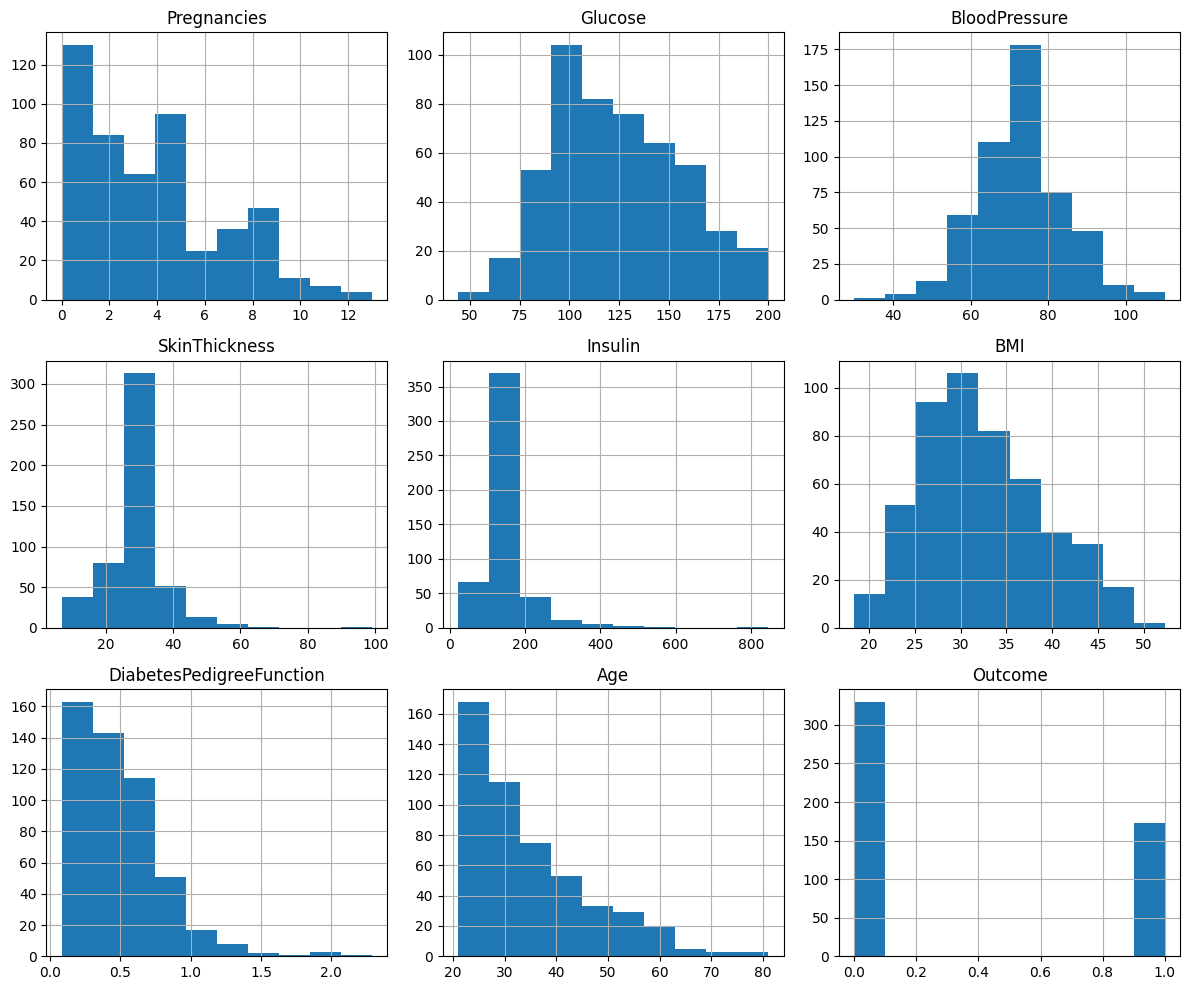

In [30]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

## 8. Outlier Detection (Boxplot)

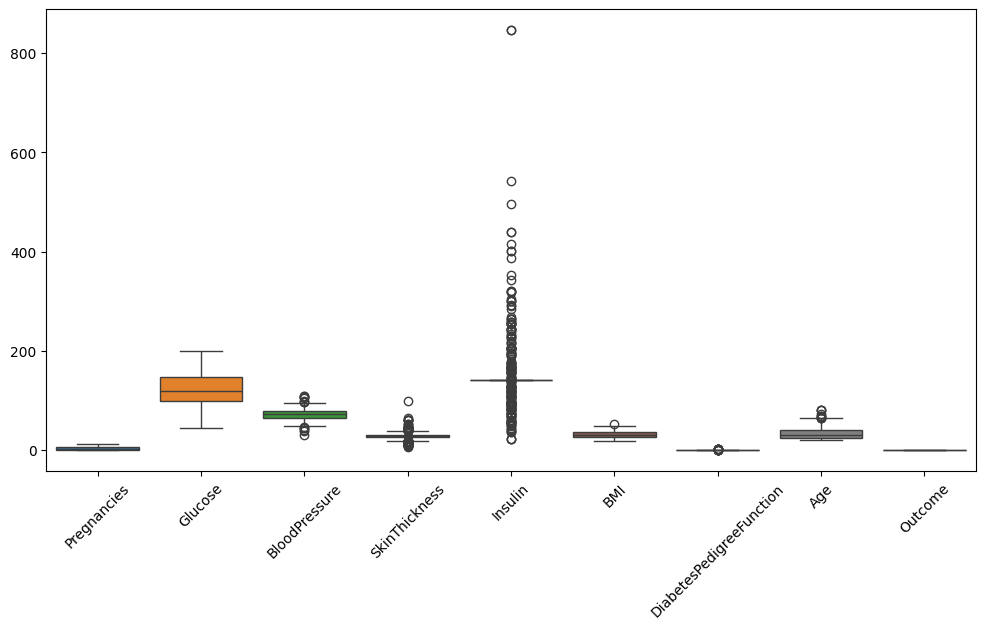

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

## 9. Remove Outliers (IQR Method)

In [32]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original shape: (503, 9)
After outlier removal: (251, 9)


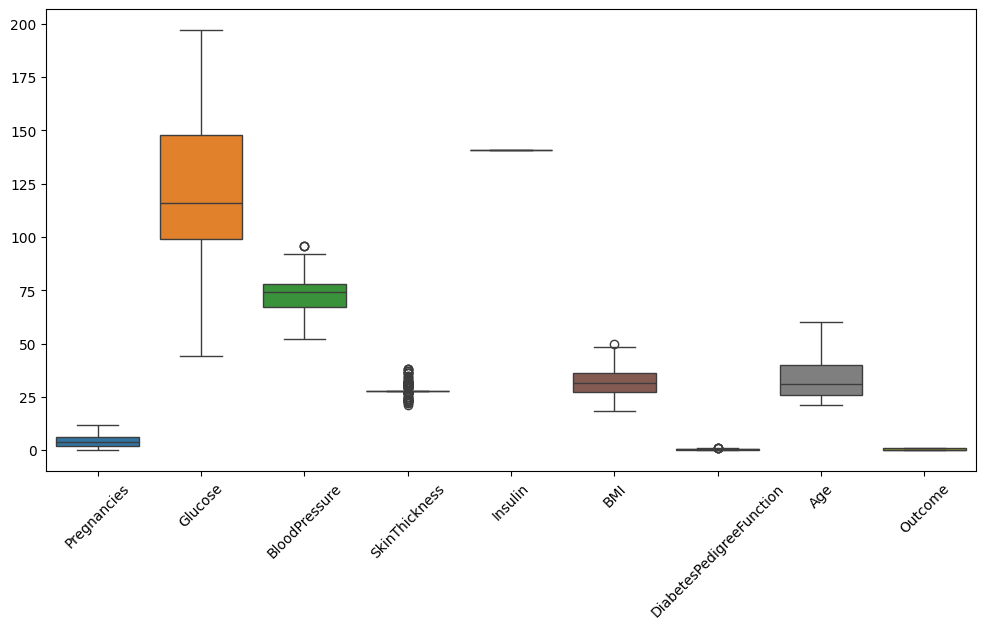

In [33]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean)
plt.xticks(rotation=45)
plt.show()

## 10. Correlation Heatmap

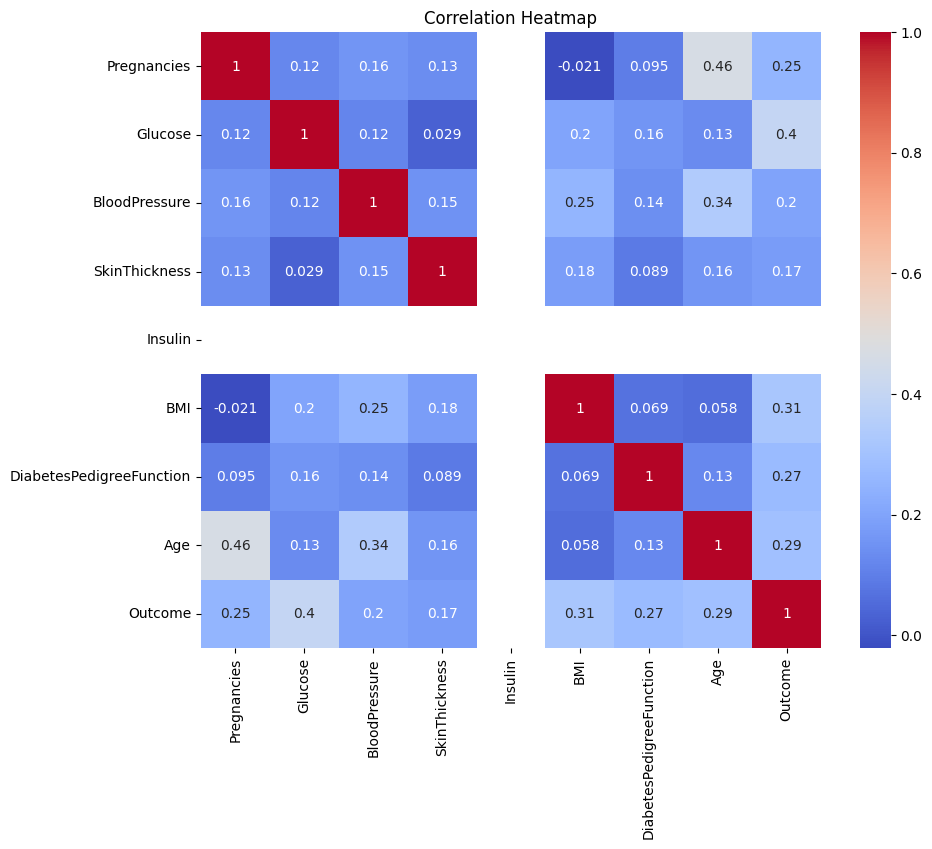

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 11. Target Distribution

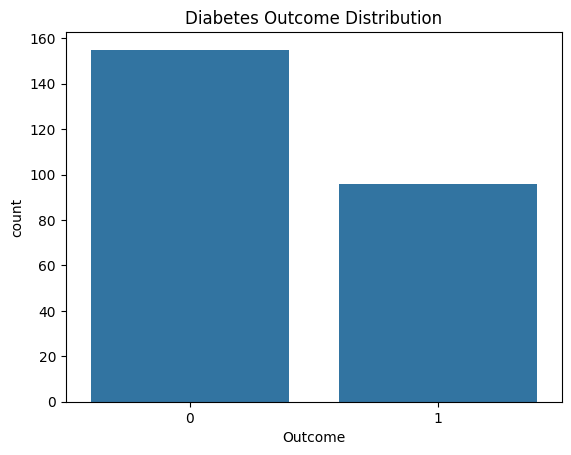

In [35]:
sns.countplot(x="Outcome", data=df_clean)
plt.title("Diabetes Outcome Distribution")
plt.show()